In [1]:
%matplotlib widget 
# Uncomment for interactive plots when running the notebook!

import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from time import perf_counter

import import_ipynb

import PyPO
from PyPO.System import System
from PyPO.Enums import Projections, Objects, Units, Scales, FieldComponents, CurrentComponents

In [2]:
# This code allows us to display global variables within markdown output, by overriding the %%markdown magic
from IPython.display import Markdown
from IPython.core.magic import register_cell_magic

@register_cell_magic
def markdown(line, cell):
    return Markdown(cell.format(**globals()))

# Import the system from `sma_beamwaveguide_setup`

2026-03-21 16:59:29 - WARNING - System override set to True. 
Primary Focal Length (F_p) : 2.520 m
Primary Rim Height (h_p): 0.893 m
Angle of edge ray (alpha) :61.52543906847784°
Vertical distance from prime focus to secondary edge plane (z_sedge1): 0.094917 m
Distance from prime focus to secondary edge plane (r_sedge1): 0.094916667 m
Angle of edge ray from Cassegrain focus to secondary edge (thetae) 2.0462388063868757°
Distance from Cassegrain focus to secondary edge (r_sedge2) 4.901135272577161 m
Subreflector eccentricity (e_s): 1.0618612323260763

Subreflector conic constant (k): -1.1275492767170534
Subreflector distance to vertex (a_s) : 2.351025969621911 m
Subreflector distance to focus (c_s): 2.496463333333331 m
Subreflector distance between foci (2 c_s) : 4.992926666666662 m
Ratio between distance between foci and Primary focal length (2 c_s/F_p) : 1.981320105820104
Subreflector (b_s) : 0.8396463927398957 m

Subreflector radius of curvature on axis (R_s): 0.28240193053417684 m
S

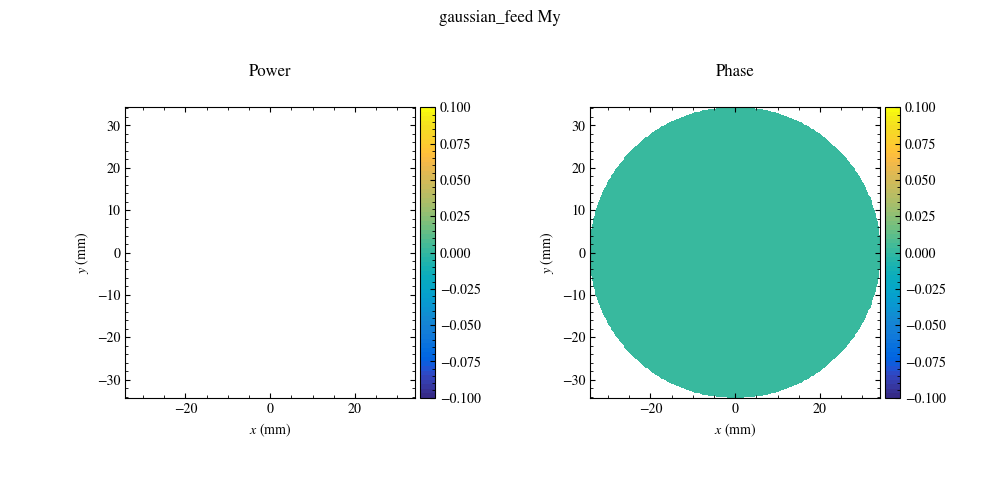

820.408910848911
Estimated Grid size : (341, 820)
Maximum Grid size   : (269, 1691)
2026-03-21 16:59:30 - INFO - Added hyperboloid secondary to system. 
2754.444791392808
Estimated Grid size : (1147, 2754)
Maximum Grid size   : (4615, 28999)
2026-03-21 16:59:30 - INFO - Added paraboloid primary to system. 
2026-03-21 16:59:30 - INFO - Added plane sec_plane to system. 
2026-03-21 16:59:30 - INFO - Translated element sec_plane by ('0.000e+00', '0.000e+00', '2.425e+03') millimeters. 
2026-03-21 16:59:30 - INFO - Added plane farfield_plane to system. 
Radius of feed image: a_sr = 228.6 mm
Beam radius: w_sr = 147.1 mm
Magnification: m = 0.2057
Distance from virtual feed to M5 : L_1 = 2941.0 mm
Distance from M4 to secondary : L_4 = 4901.1 mm
Distance from intermediate image to M5 : L_2 = 964.9 mm
Distance from intermediate image to M4 : L_3 = 330.8 mm
z position of intermediate image : z_i = 3125.9 mm
beam radius of intermediate image : w_i = 9.9245 mm
focal length of M5 : f_M5 = 726.529 mm


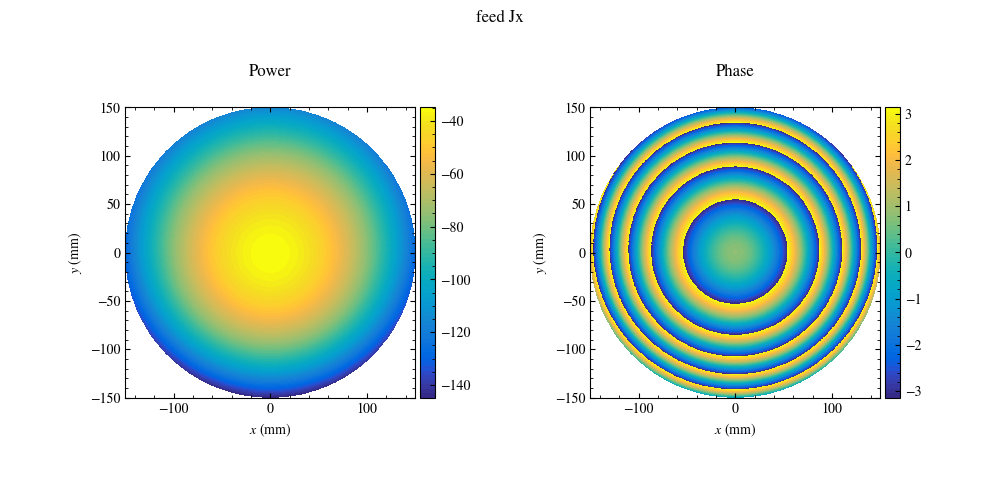

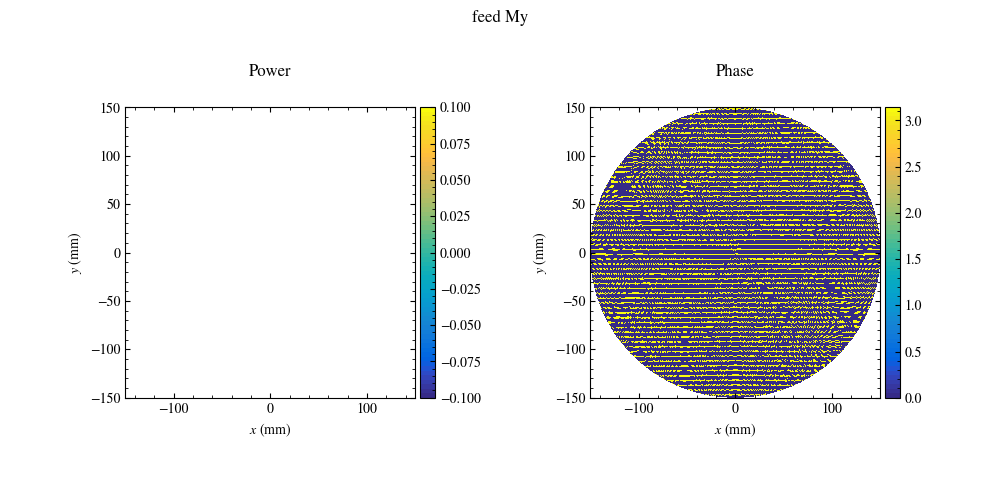

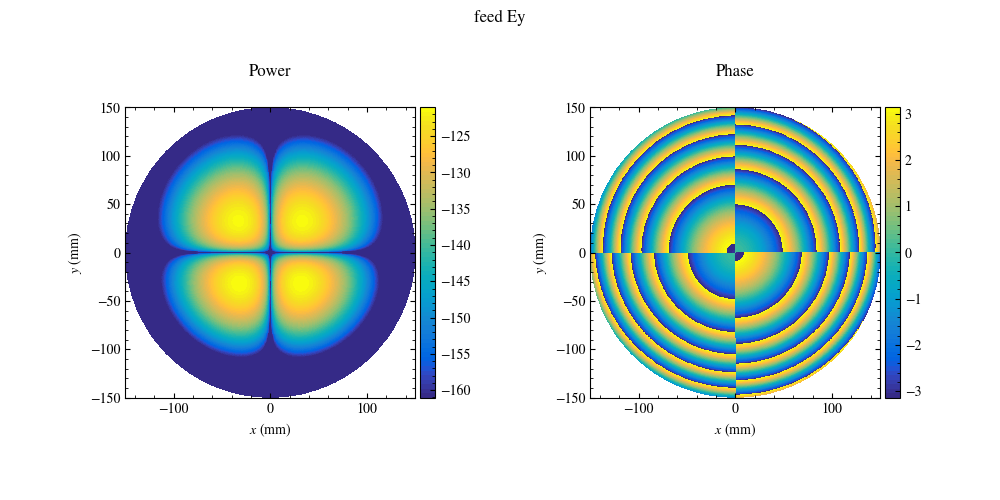

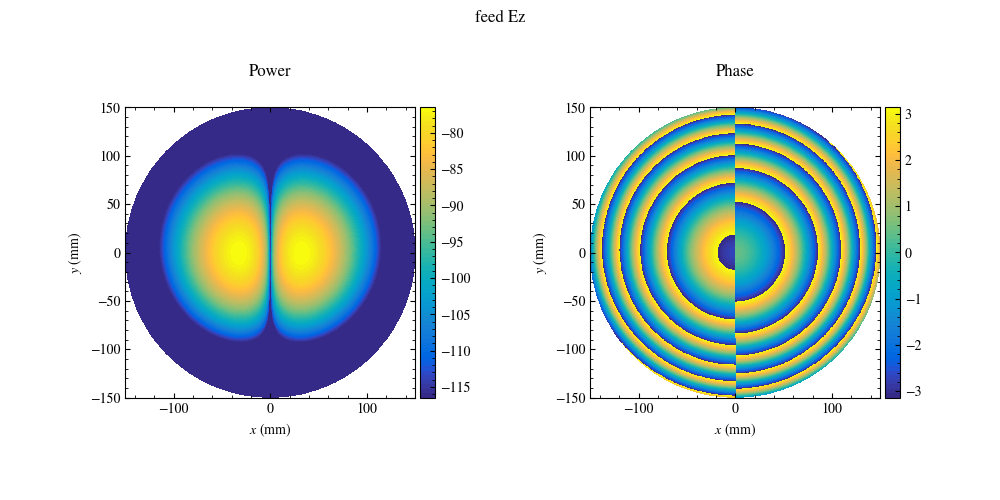

2026-03-21 16:59:37 - INFO - Translated element flat_M6 by ('0.000e+00', '0.000e+00', '-4.172e+03') millimeters. 
2026-03-21 16:59:41 - INFO - Rotated element flat_M6 by ('-9.000e+01', '1.800e+02', '0.000e+00') degrees around ('0.000e+00', '0.000e+00', '-2.041e+03'). 
2026-03-21 16:59:44 - INFO - Rotated element flat_M6 by ('0.000e+00', '0.000e+00', '1.302e+02') degrees around ('1.192e-11', '-4.351e+02', '-2.041e+03'). 
2026-03-21 16:59:48 - INFO - Rotated element flat_M6 by ('0.000e+00', '0.000e+00', '2.298e+02') degrees around ('9.896e+02', '4.012e+02', '-2.041e+03'). 
Nominal M5-M6 distance: 400.00 mm
Actual M5-M6 distance: 400.00 mm


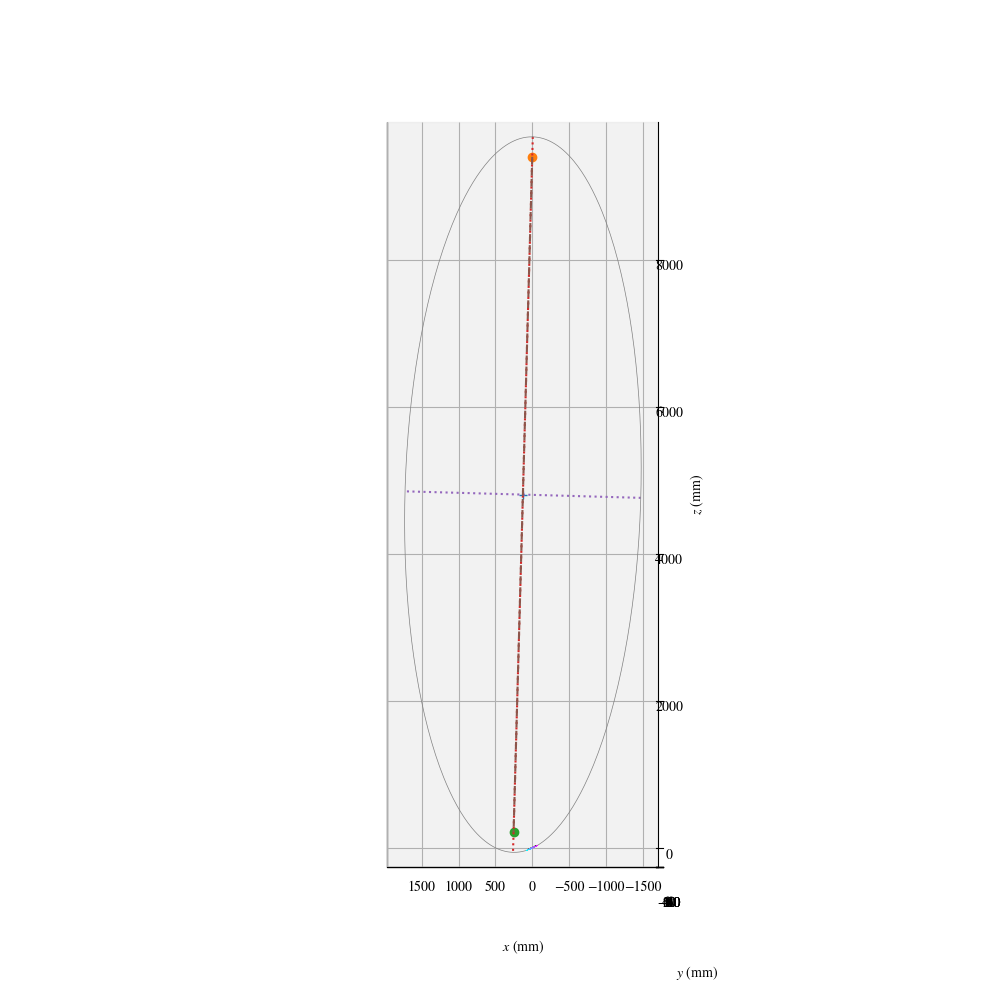

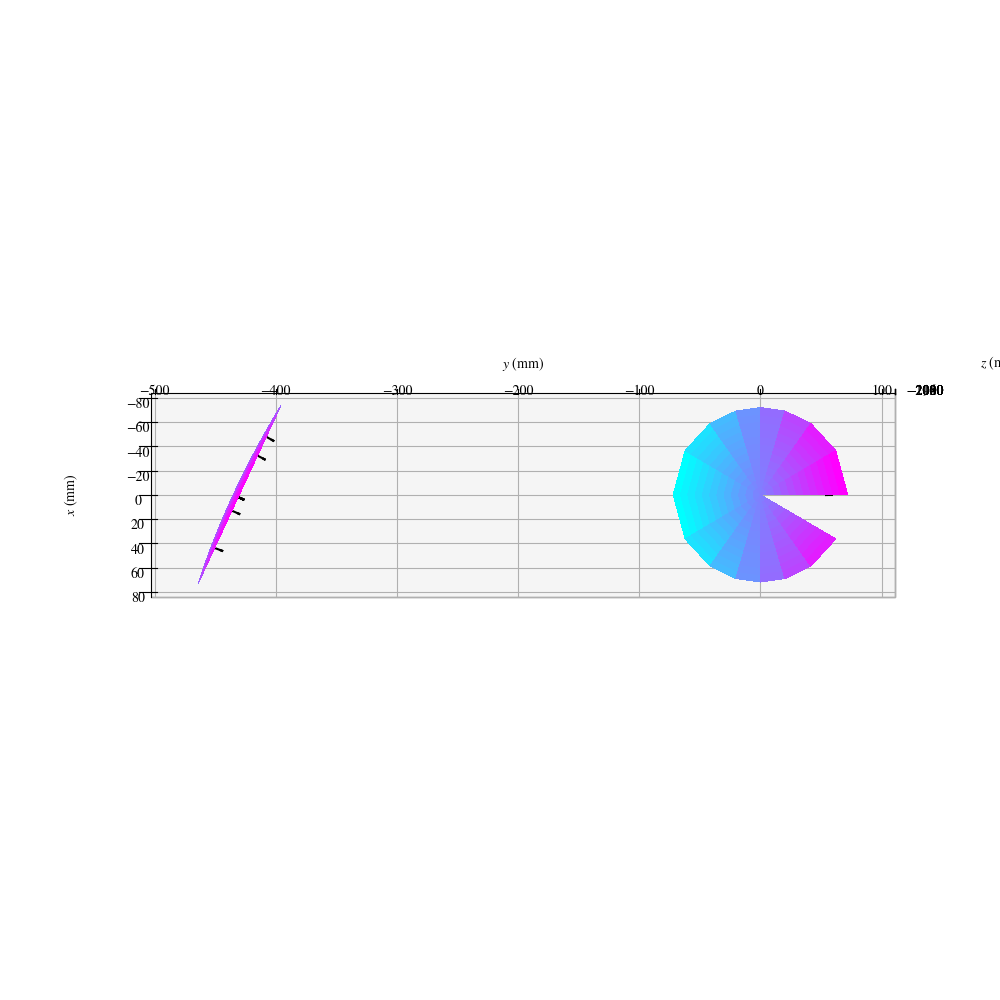

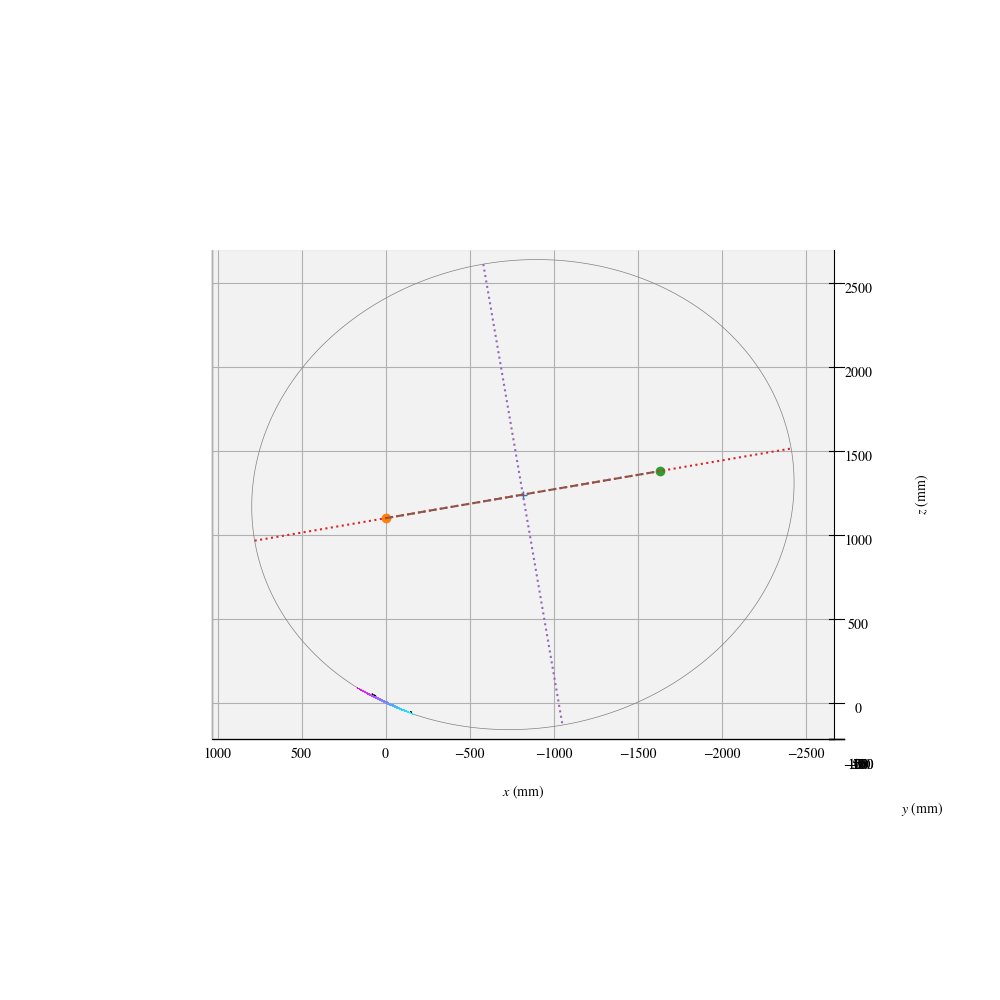

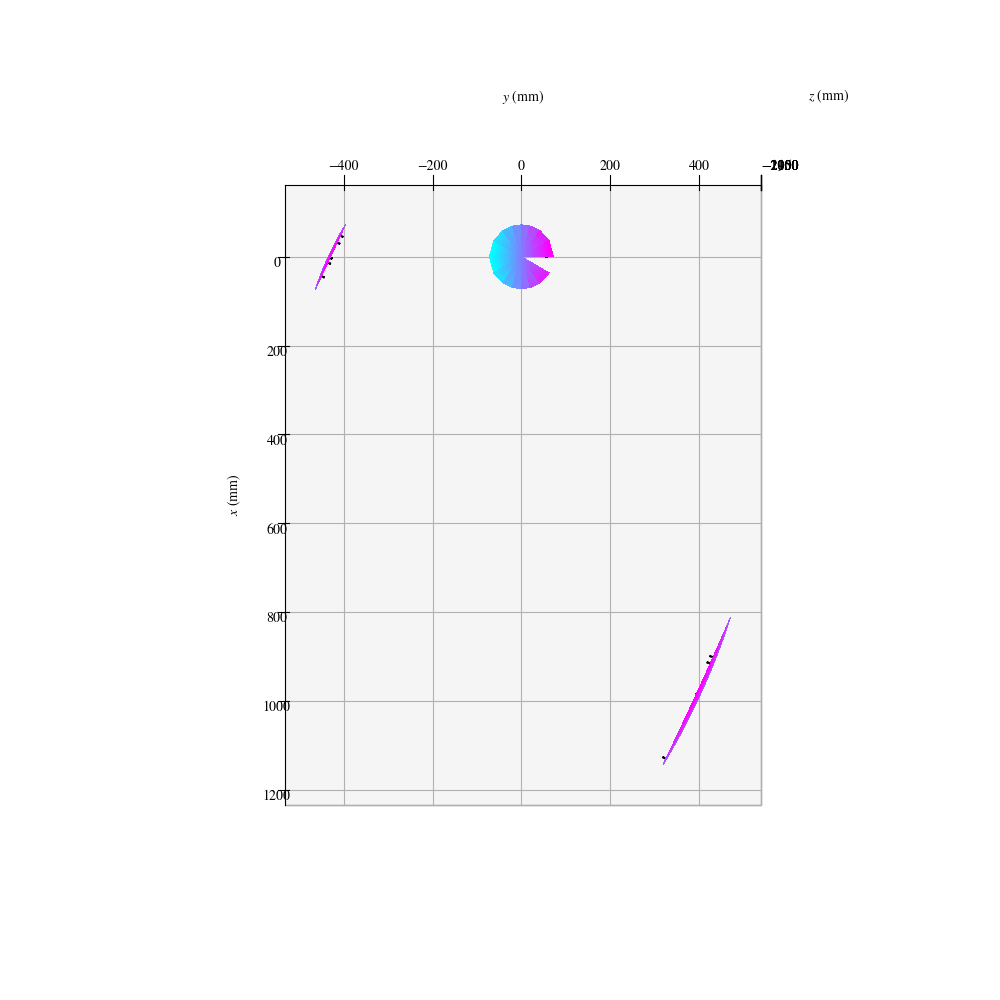

In [3]:
from sma_beamwaveguide_setup import s, M4M5_bendangle
bend_angle=np.deg2rad(M4M5_bendangle)

# Calculation

Now that we have set up the system correctly, we can start running Physical optics to calculate the performance of the beam waveguide

In [4]:
from time import perf_counter

step_times = []

In [5]:
# Set up our choice of calculation method.
method = 'GPU'
if method == 'CPU':
    nThreads = 24
else:
    nThreads = 256
mode = 'JMEH'

epsilon = 1.0

## VF to M6 Physical Optics

In [6]:
# vf_to_M6_PO = {
#     "t_name"    : "flat_M6",
#     "s_current" : "feed",
#     "mode"      : "JMEH",
#     "name_JM"   : "M6_JM",
#     "name_EH"   : "M6_EH",
#     "device"    : method,
#     "nThreads"  : nThreads
# }

# start = perf_counter()
# s.runPO(vf_to_M6_PO)
# step_times.append(perf_counter()-start)

In [7]:
s.system['flat_M6']['gridsize']

array([ 464, 1440])

In [8]:
M6_grid = s.generateGrids('flat_M6')

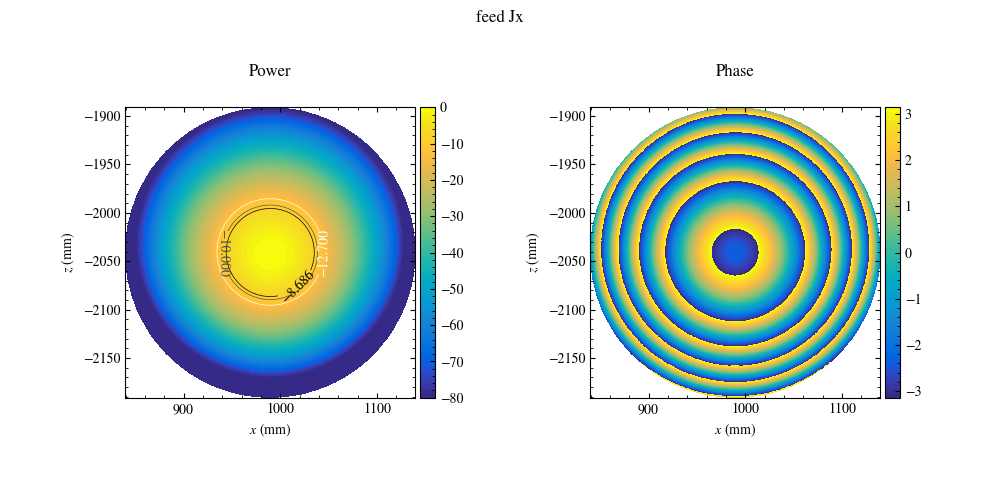

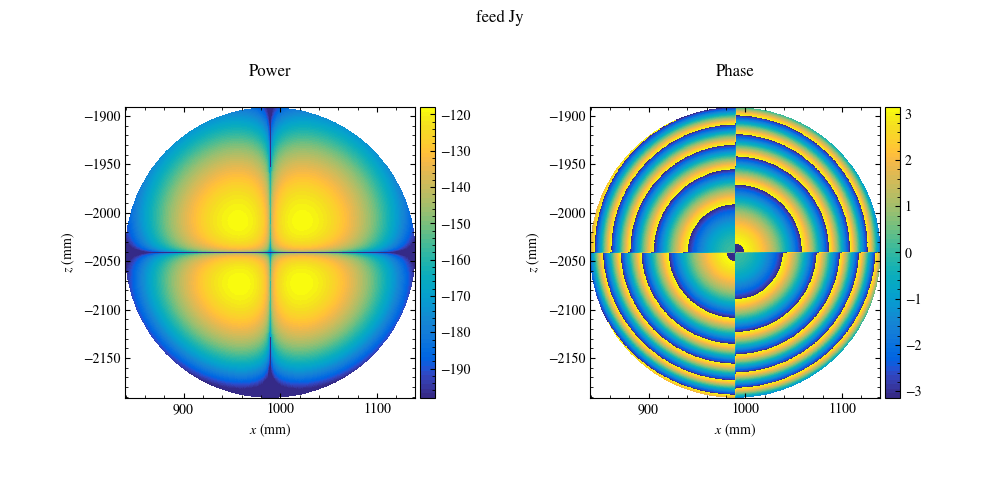

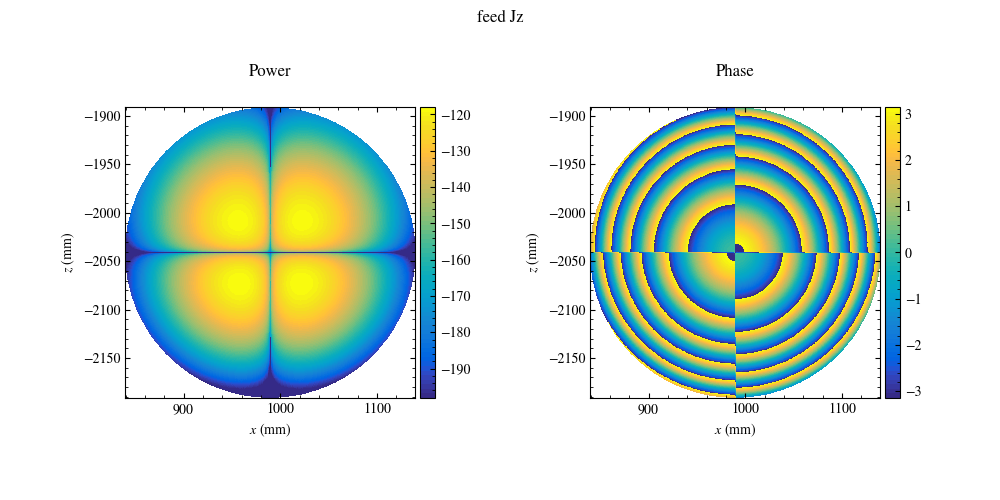

In [9]:
phasevect = np.array((0, 1, 0))

s.plotBeam2D("feed", CurrentComponents.Jx, vmin=-80, norm=True, project=Projections.xz, \
    contour="feed", contour_comp=CurrentComponents.Jx, levels=[-12.7,-10.0, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

s.plotBeam2D("feed", CurrentComponents.Jy, vmin=-80, norm=False, project=Projections.xz, \
    contour="feed", contour_comp=CurrentComponents.Jy, levels=[-12.7,-10.0, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

s.plotBeam2D("feed", CurrentComponents.Jz, vmin=-80, norm=False, project=Projections.xz, \
    contour="feed", contour_comp=CurrentComponents.Jz, levels=[-12.7,-10.0, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

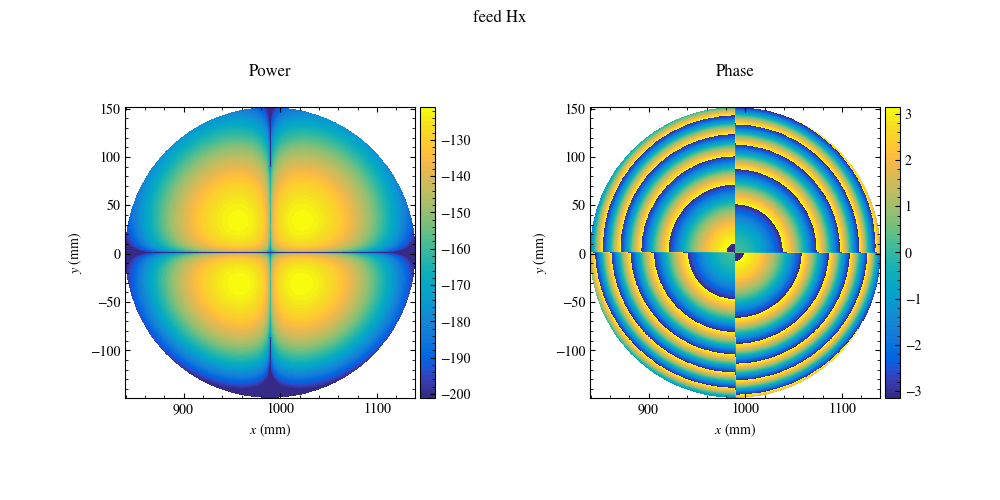

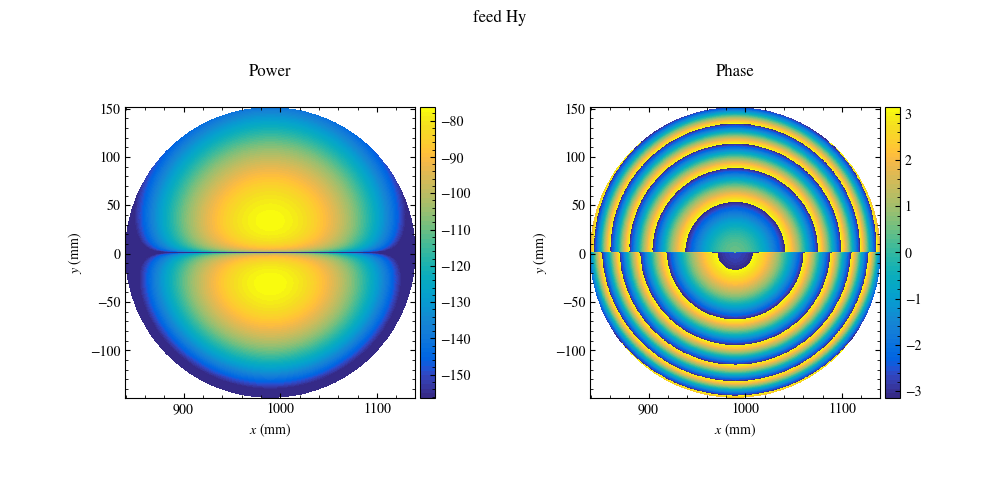

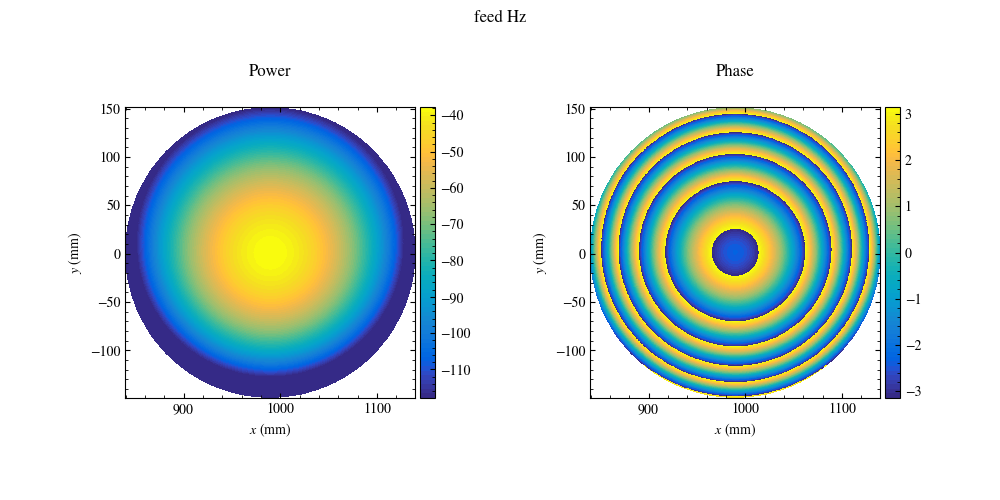

In [10]:
phasevect = np.array((0, 1, 0))

s.plotBeam2D("feed", FieldComponents.Hx, vmin=-80, norm=False, project=Projections.xy, \
    contour="feed", contour_comp=FieldComponents.Hx, levels=[-12.7,-10.0, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

s.plotBeam2D("feed", FieldComponents.Hy, vmin=-80, norm=False, project=Projections.xy, \
    contour="feed", contour_comp=FieldComponents.Hy, levels=[-12.7,-10.0, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

s.plotBeam2D("feed", FieldComponents.Hz, vmin=-80, norm=False, project=Projections.xy, \
    contour="feed", contour_comp=FieldComponents.Hz, levels=[-12.7,-10.0, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

## M6 to M5 Physical Optics

In [11]:
M6_to_M5_PO = {
    "t_name"    : "quadric_M5",
    "s_current" : "feed",
    "mode"      : "JMEH",
    "name_JM"   : "M5_JM",
    "name_EH"   : "M5_EH",
    "device"    : method,
    "nThreads"  : nThreads
}


In [12]:
s.system['quadric_M5']['gridsize']

array([23, 59])

In [13]:
s.system['quadric_M5']['gridsize'] = np.array([401,960])

In [14]:
start = perf_counter()
s.runPO(M6_to_M5_PO)
step_times.append(perf_counter()-start)

2026-03-21 17:00:17 - WORK - *** Starting PO propagation *** 
2026-03-21 17:00:17 - WORK - Propagating feed on flat_M6 to quadric_M5, propagation mode: JMEH. 
2026-03-21 17:00:17 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:00:17 - WORK - ... Calculating ... 
2026-03-21 17:01:00 - WORK - *** Finished: 43.082 seconds *** 


In [15]:
phasevect = np.array((np.sin(2*bend_angle), np.cos(2*bend_angle), 0))

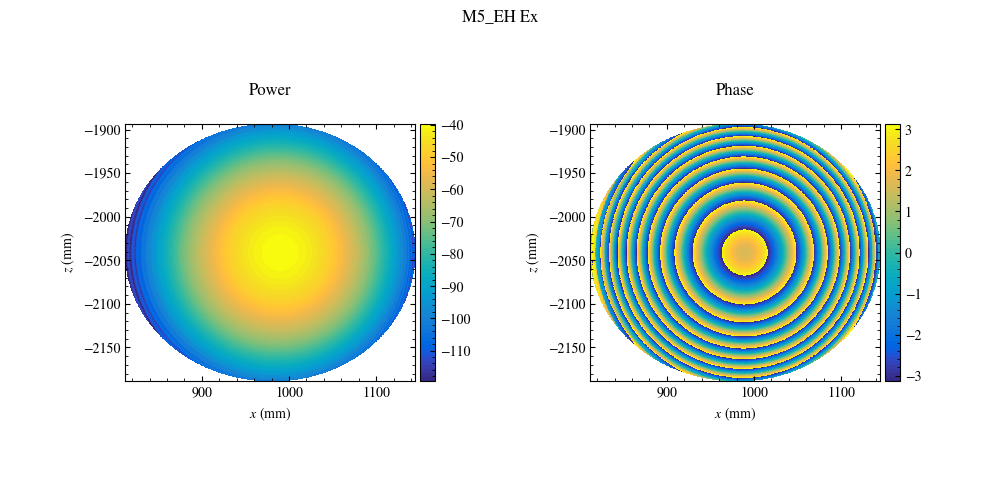

In [16]:
fig, ax = s.plotBeam2D("M5_EH", FieldComponents.Ex, project=Projections.xz, vmin = -80, norm=False, \
                        contour="M5_EH", contour_comp=FieldComponents.Ex, levels=[-12.7, 20*np.log10(np.exp(-1))], \
                        correct_phase=phasevect, ret=True)
fig.savefig('Beamwaveguide_M5_Ex')

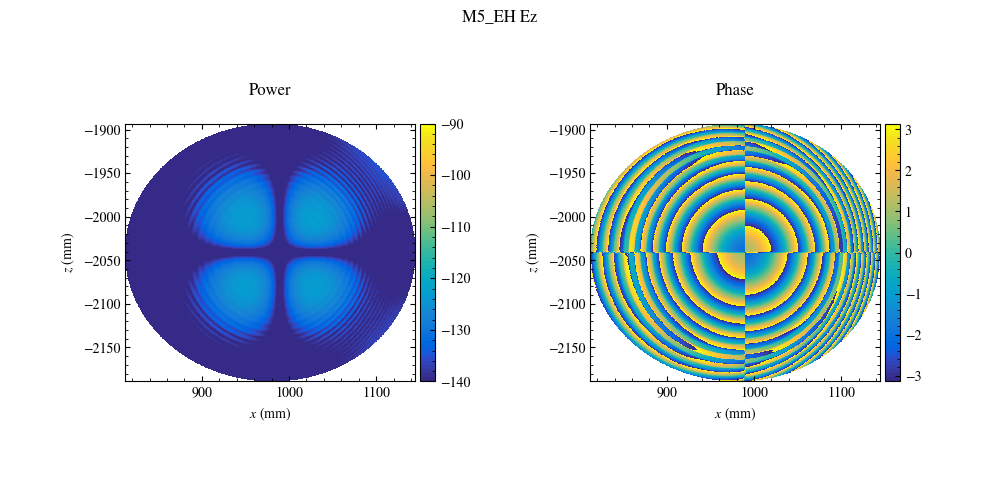

In [17]:
fig, ax = s.plotBeam2D("M5_EH", FieldComponents.Ez, project=Projections.xz, vmax=-90, vmin = -50, norm=False, \
                        contour="M5_EH", contour_comp=FieldComponents.Ez, levels=[-12.7, 20*np.log10(np.exp(-1))], \
                        correct_phase=phasevect, ret=True)
fig.savefig("Beamwaveguide_M5_Ez.png")

## M5 to M4 Physical Optics

In [18]:
M5_to_M4_PO = {
    "t_name"    : "quadric_M4",
    "s_current" : "M5_JM",
    "mode"      : "JMEH",
    "name_JM"   : "M4_JM",
    "name_EH"   : "M4_EH",
    "device"    : method,
    "nThreads"  : nThreads
}


In [19]:
s.system['quadric_M4']['gridsize'] = np.array([301, 720])

In [20]:

start = perf_counter()
s.runPO(M5_to_M4_PO)
step_times.append(perf_counter()-start)

2026-03-21 17:01:06 - WORK - *** Starting PO propagation *** 
2026-03-21 17:01:06 - WORK - Propagating M5_JM on quadric_M5 to quadric_M4, propagation mode: JMEH. 
2026-03-21 17:01:06 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:01:06 - WORK - ... Calculating ... 
2026-03-21 17:01:21 - WORK - *** Finished: 15.233 seconds *** 


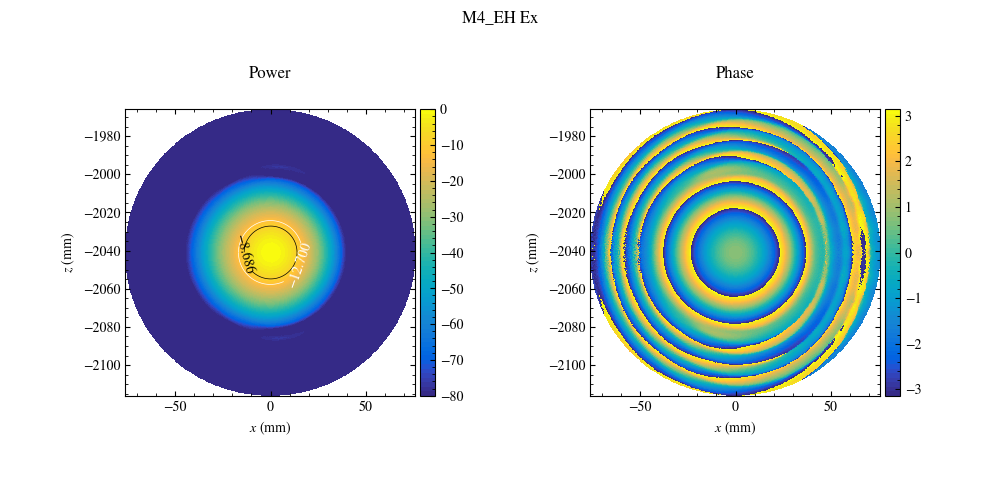

In [21]:
phasevect = np.array((np.sin(2*bend_angle), np.cos(2*bend_angle), 0))

s.plotBeam2D("M4_EH", FieldComponents.Ex, project=Projections.xz, vmin=-80, \
    contour="M4_EH", contour_comp=FieldComponents.Ex, levels=[-12.7, 20*np.log10(np.exp(-1))], \
    correct_phase=phasevect)

fig.savefig("Beamwaveguide_M4_Ex.png")

## M4 to M3 Physical Optics

In [22]:
M4_to_M3_PO = {
    "t_name"    : "flat_M3",
    "s_current" : "M4_JM",
    "mode"      : "JMEH",
    "name_JM"   : "M3_JM",
    "name_EH"   : "M3_EH",
    "device"    : method,
    "nThreads"  : nThreads
}


In [23]:
s.system['flat_M3']['gridsize'] = np.array([101,180])

In [24]:

start = perf_counter()
s.runPO(M4_to_M3_PO)
step_times.append(perf_counter() - start)

2026-03-21 17:01:24 - WORK - *** Starting PO propagation *** 
2026-03-21 17:01:24 - WORK - Propagating M4_JM on quadric_M4 to flat_M3, propagation mode: JMEH. 
2026-03-21 17:01:24 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:01:24 - WORK - ... Calculating ... 
2026-03-21 17:01:26 - WORK - *** Finished: 2.182 seconds *** 


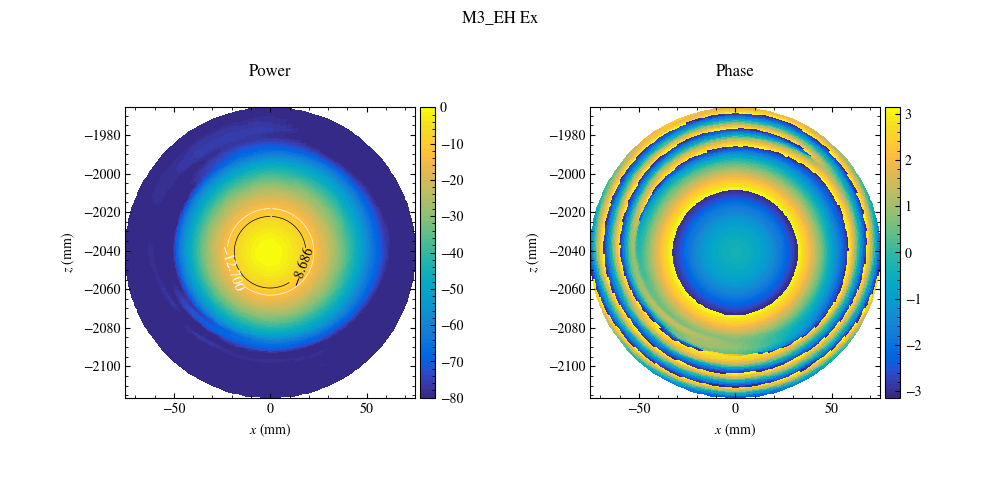

In [25]:
s.plotBeam2D("M3_EH", FieldComponents.Ex, project=Projections.xz, vmin=-80, \
    contour="M3_EH", contour_comp=FieldComponents.Ex, levels=[-12.7, 20*np.log10(np.exp(-1))], \
    correct_phase=[0,0,-1])

fig.savefig("Beamwaveguide_M3_Ex.png")

## M3 to Secondary Physical Optics

In [26]:
M3_to_Sec_PO = {
    "t_name"    : "secondary",
    "s_current" : "M3_JM",
    "mode"      : "JMEH",
    "name_JM"   : "Sec_JM",
    "name_EH"   : "Sec_EH",
    "device"    : method,
    "nThreads"  : nThreads
}

start = perf_counter()
s.runPO(M3_to_Sec_PO)
step_times.append(perf_counter()-start)

2026-03-21 17:01:29 - WORK - *** Starting PO propagation *** 
2026-03-21 17:01:29 - WORK - Propagating M3_JM on flat_M3 to secondary, propagation mode: JMEH. 
2026-03-21 17:01:29 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:01:29 - WORK - ... Calculating ... 
2026-03-21 17:01:31 - WORK - *** Finished: 1.968 seconds *** 


In [27]:
s.system["secondary"]["gridsize"]

array([315, 780])

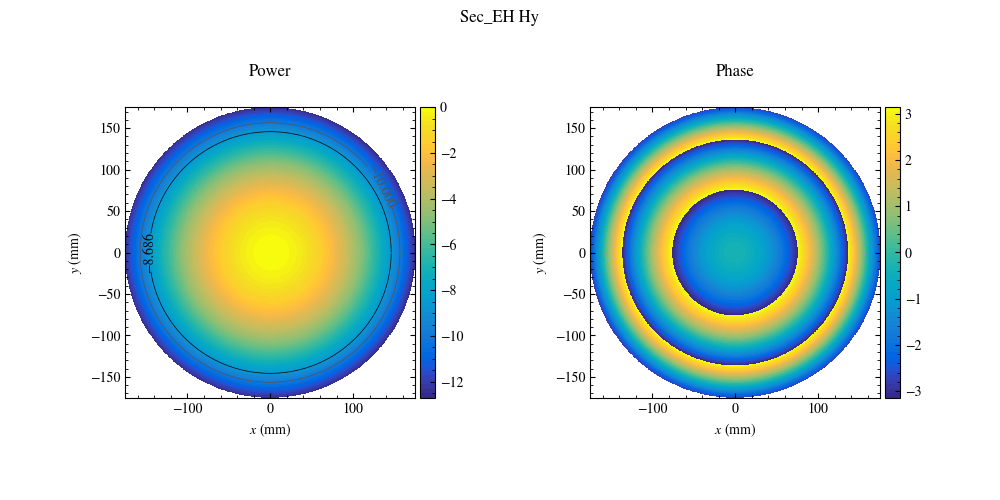

In [28]:
fig, ax = s.plotBeam2D("Sec_EH", FieldComponents.Hy, project=Projections.xy, vmin=-12.7, \
             contour="Sec_EH", contour_comp=FieldComponents.Ex, levels=[-12.7, -10, 20*np.log10(np.exp(-1))], \
             correct_phase=1, ret=True)

fig.savefig("Beamwaveguide_Sec_Hy.png")

In [29]:
Sec_to_Pri_PO = {
    "t_name"    : "primary",
    "s_current" : "Sec_JM",
    "mode"      : "JMEH",
    "name_JM"   : "Pri_JM",
    "name_EH"   : "Pri_EH",
    "device"    : method,
    "nThreads"  : nThreads
}


In [30]:
s.system['primary']['gridsize']

array([260,  80])

In [31]:
s.system['primary']['gridsize'] = np.array((380, 740))

In [32]:

start = perf_counter()
s.runPO(Sec_to_Pri_PO)
step_times.append(perf_counter()-start)

2026-03-21 17:01:35 - WORK - *** Starting PO propagation *** 
2026-03-21 17:01:35 - WORK - Propagating Sec_JM on secondary to primary, propagation mode: JMEH. 
2026-03-21 17:01:35 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:01:35 - WORK - ... Calculating ... 
2026-03-21 17:01:47 - WORK - *** Finished: 12.409 seconds *** 


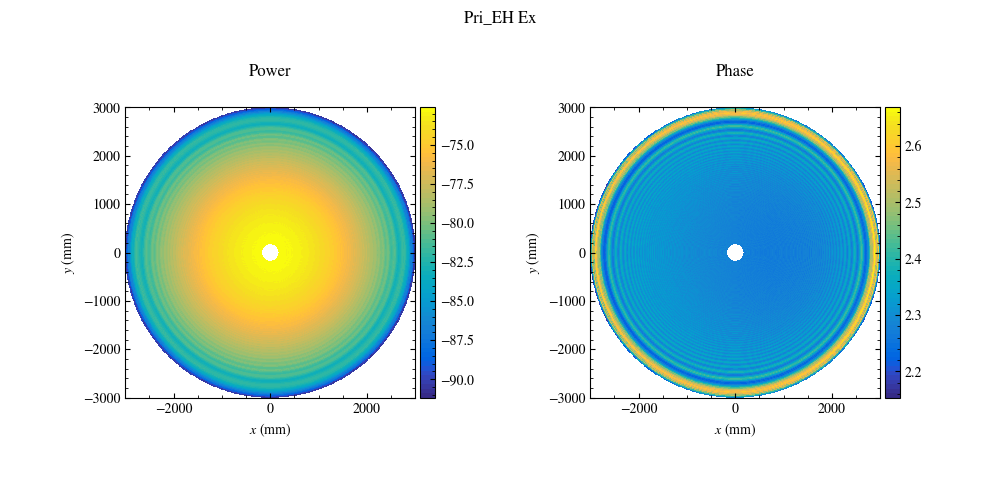

In [33]:
s.plotBeam2D("Pri_EH", FieldComponents.Ex, project=Projections.xy, norm=False, correct_phase=-1)

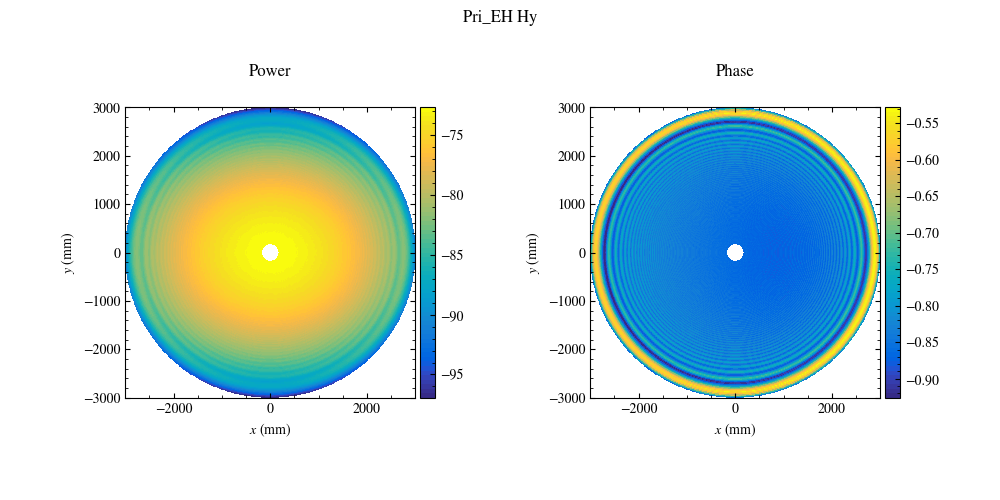

In [34]:
s.plotBeam2D("Pri_EH", FieldComponents.Hy, project=Projections.xy, norm=False, correct_phase=-1)

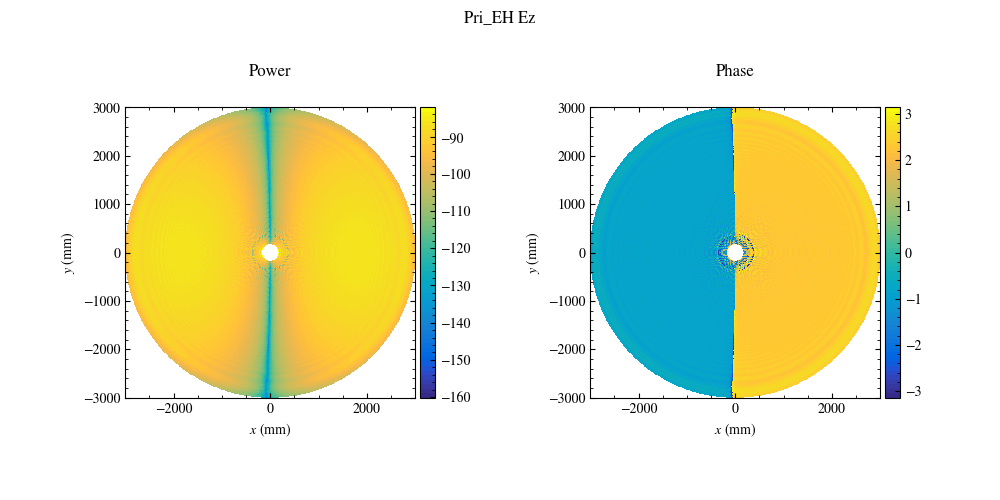

In [35]:
s.plotBeam2D("Pri_EH", FieldComponents.Ez, project=Projections.xy, norm=False, correct_phase=-1)

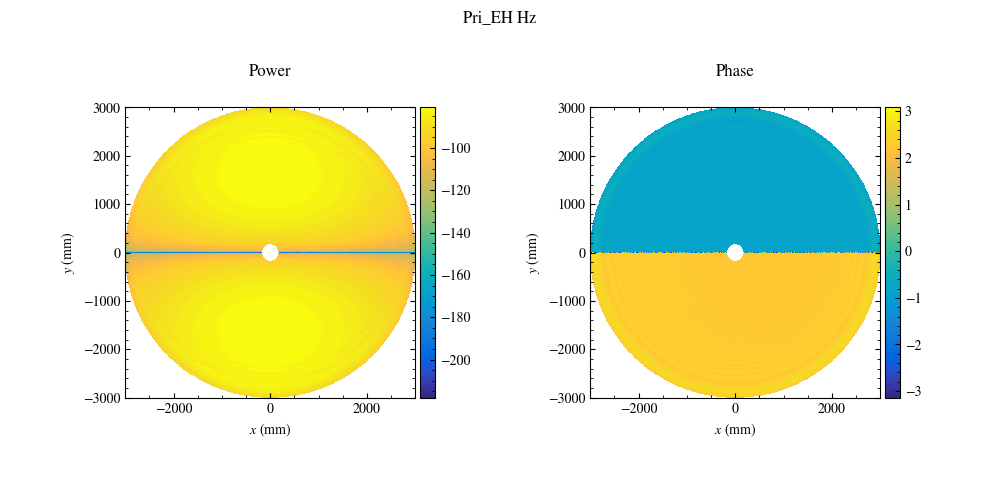

In [36]:
s.plotBeam2D("Pri_EH", FieldComponents.Hz, project=Projections.xy, norm=False, correct_phase=-1)

## Propagate to the far field

In [37]:
plane_ff = {
            "name"      : "plane_ff",
            "gmode"     : "AoE",
            "lims_Az"    : np.array([-1.0, 1.0])*.2,
            "lims_El"    : np.array([-1.0, 1.0])*.2,
            "gridsize"  : np.array([301, 301])
            }
s.addPlane(plane_ff)

par_to_plane_ff_PO = {
    "t_name"      : "plane_ff",
    "s_current"   : "Pri_JM",
    "mode"        : "FF",
    "name_EH"     : "EH_FF",
    "device"    : method,
    "nThreads"  : nThreads
}

sec_to_plane_ff_PO = {
    "t_name"      : "plane_ff",
    "s_current"   : "Sec_JM",
    "mode"        : "FF",
    "name_EH"     : "EH_FF_Sec",
    "device"    : method,
    "nThreads"  : nThreads
}

M3_to_plane_ff_PO = {
    "t_name"      : "plane_ff",
    "s_current"   : "M3_JM",
    "mode"        : "FF",
    "name_EH"     : "EH_FF_M3",
    "device"    : method,
    "nThreads"  : nThreads
}


start = perf_counter()
s.runPO(par_to_plane_ff_PO)
step_times.append(perf_counter()-start)

start = perf_counter()
s.runPO(sec_to_plane_ff_PO)
step_times.append(perf_counter()-start)

start = perf_counter()
s.runPO(M3_to_plane_ff_PO)
step_times.append(perf_counter()-start)

2026-03-21 17:01:54 - INFO - Added plane plane_ff to system. 
2026-03-21 17:01:54 - WORK - *** Starting PO propagation *** 
2026-03-21 17:01:54 - WORK - Propagating Pri_JM on primary to plane_ff, propagation mode: FF. 
2026-03-21 17:01:54 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:01:54 - WORK - ... Calculating ... 
2026-03-21 17:01:59 - WORK - *** Finished: 4.941 seconds *** 
2026-03-21 17:01:59 - WORK - *** Starting PO propagation *** 
2026-03-21 17:01:59 - WORK - Propagating Sec_JM on secondary to plane_ff, propagation mode: FF. 
2026-03-21 17:01:59 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:01:59 - WORK - ... Calculating ... 
2026-03-21 17:02:01 - WORK - *** Finished: 2.250 seconds *** 
2026-03-21 17:02:01 - WORK - *** Starting PO propagation *** 
2026-03-21 17:02:01 - WORK - Propagating M3_JM on flat_M3 to plane_ff, propagation mode: FF. 
2026-03-21 17:02:01 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:

In [38]:
plane_ff_large = {
            "name"      : "plane_ff_large",
            "gmode"     : "AoE",
            "lims_Az"    : np.array([-1.0, 1.0])*2,
            "lims_El"    : np.array([-1.0, 1.0])*2,
            "gridsize"  : np.array([1001, 1001])
            }
s.addPlane(plane_ff_large)

par_to_plane_ff_PO = {
    "t_name"      : "plane_ff_large",
    "s_current"   : "Pri_JM",
    "mode"        : "FF",
    "name_EH"     : "EH_FF_large",
    "device"    : method,
    "nThreads"  : nThreads
}

sec_to_plane_ff_PO = {
    "t_name"      : "plane_ff_large",
    "s_current"   : "Sec_JM",
    "mode"        : "FF",
    "name_EH"     : "EH_FF_Sec_large",
    "device"    : method,
    "nThreads"  : nThreads
}

M3_to_plane_ff_PO = {
    "t_name"      : "plane_ff_large",
    "s_current"   : "M3_JM",
    "mode"        : "FF",
    "name_EH"     : "EH_FF_M3_large",
    "device"    : method,
    "nThreads"  : nThreads
}


start = perf_counter()
s.runPO(par_to_plane_ff_PO)
step_times.append(perf_counter()-start)

start = perf_counter()
s.runPO(sec_to_plane_ff_PO)
step_times.append(perf_counter()-start)

start = perf_counter()
s.runPO(M3_to_plane_ff_PO)
step_times.append(perf_counter()-start)

2026-03-21 17:02:04 - INFO - Added plane plane_ff_large to system. 
2026-03-21 17:02:04 - WORK - *** Starting PO propagation *** 
2026-03-21 17:02:04 - WORK - Propagating Pri_JM on primary to plane_ff_large, propagation mode: FF. 
2026-03-21 17:02:04 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:02:04 - WORK - ... Calculating ... 
2026-03-21 17:02:40 - WORK - *** Finished: 35.383 seconds *** 
2026-03-21 17:02:40 - WORK - *** Starting PO propagation *** 
2026-03-21 17:02:40 - WORK - Propagating Sec_JM on secondary to plane_ff_large, propagation mode: FF. 
2026-03-21 17:02:40 - WORK - Hardware: running 256 CUDA threads per block. 
2026-03-21 17:02:40 - WORK - ... Calculating ... 
2026-03-21 17:02:45 - WORK - *** Finished: 5.614 seconds *** 
2026-03-21 17:02:45 - WORK - *** Starting PO propagation *** 
2026-03-21 17:02:45 - WORK - Propagating M3_JM on flat_M3 to plane_ff_large, propagation mode: FF. 
2026-03-21 17:02:45 - WORK - Hardware: running 256 CUDA threads p

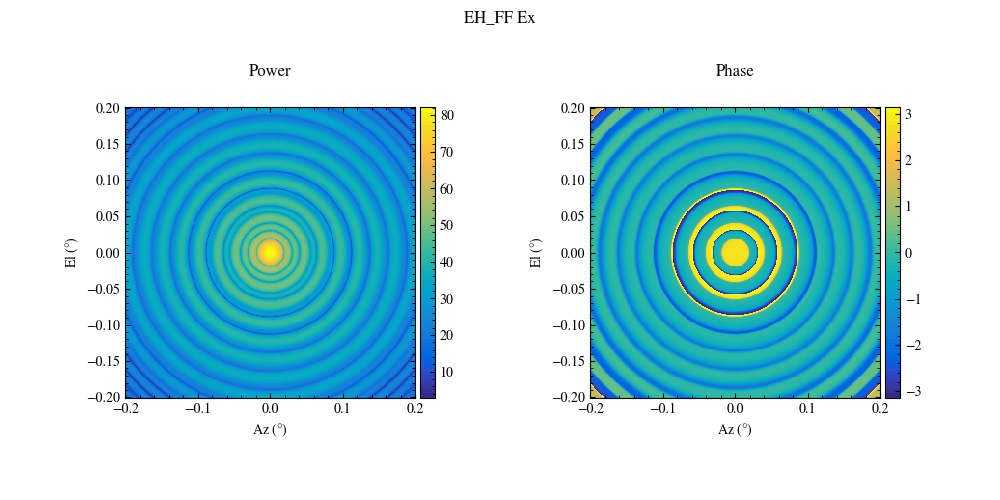

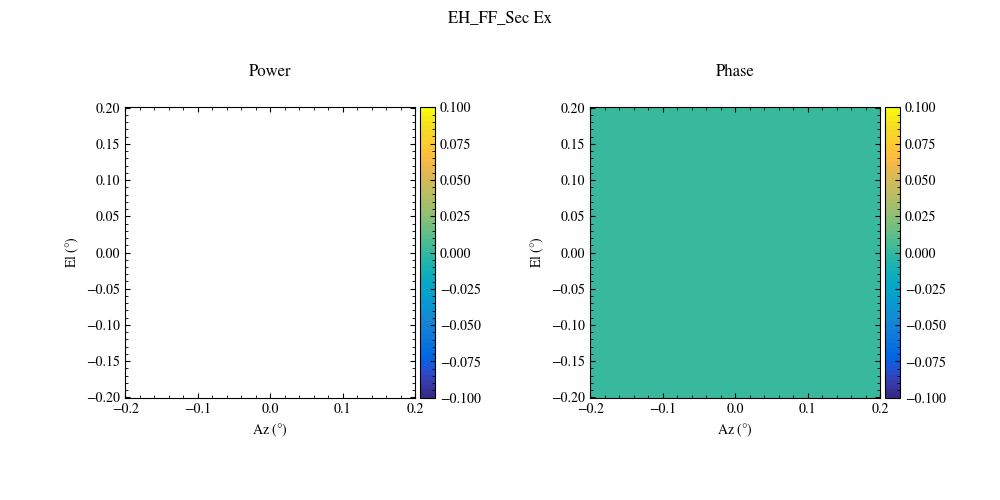

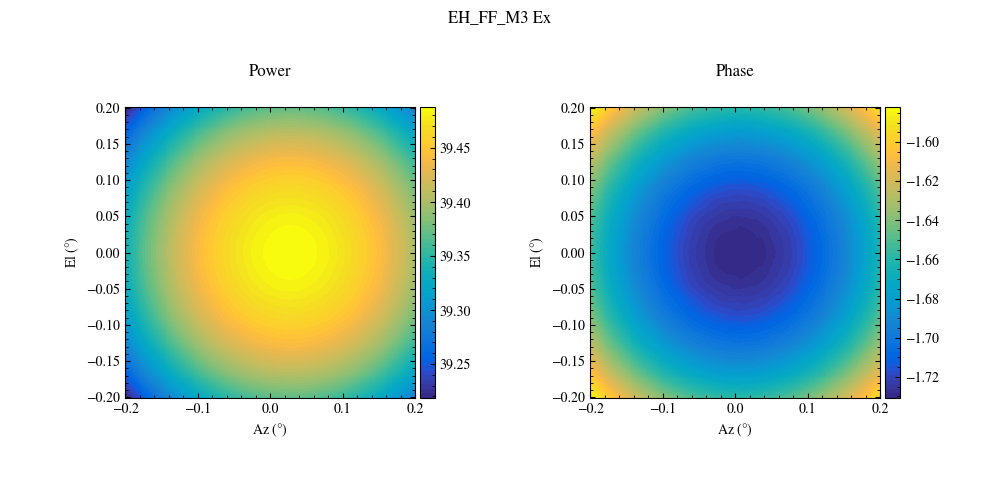

In [39]:
fig, ax = s.plotBeam2D('EH_FF', FieldComponents.Ex,  norm=False, ret=True)

fig, ax = s.plotBeam2D('EH_FF_Sec', FieldComponents.Ex,  norm=False, ret=True)

fig, ax = s.plotBeam2D('EH_FF_M3', FieldComponents.Ex,  norm=False, ret=True)

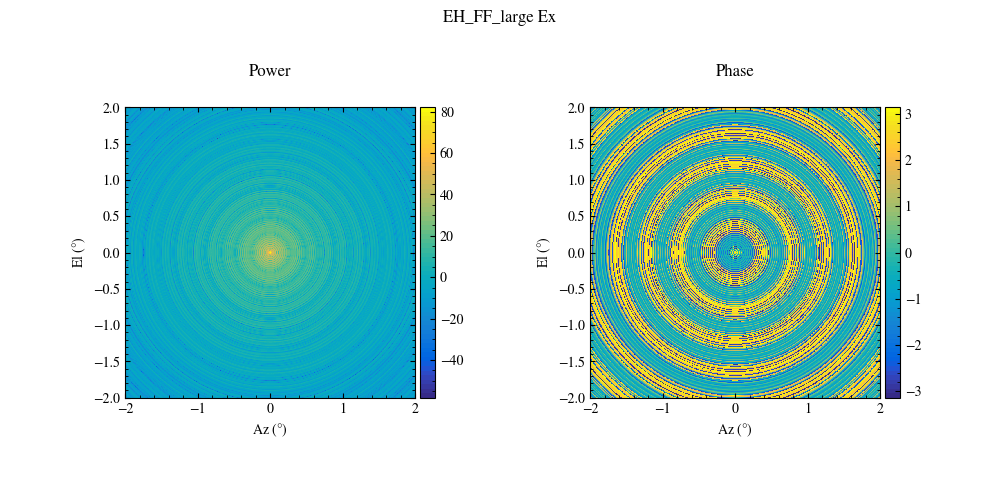

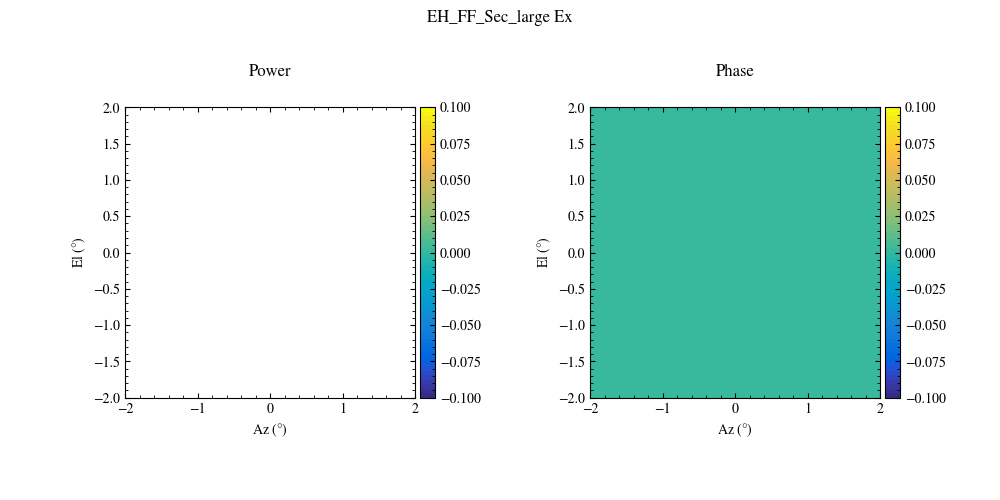

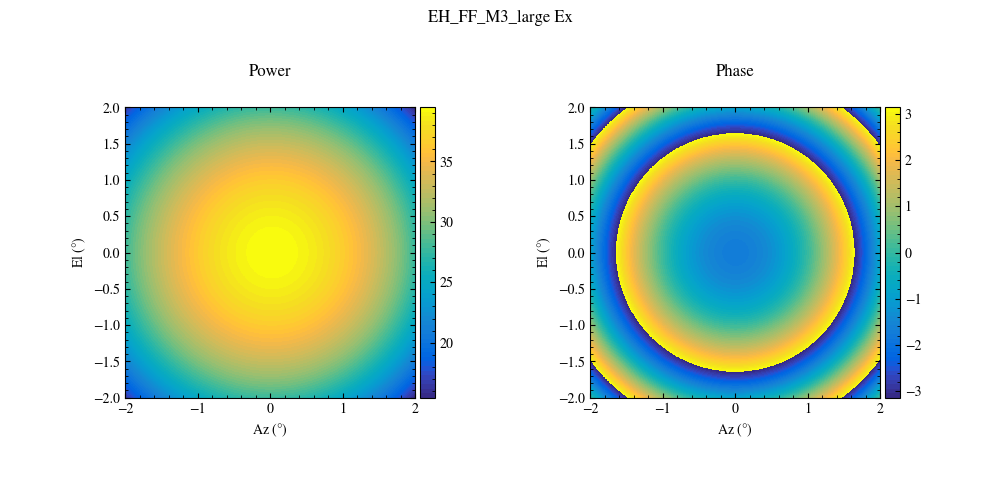

In [40]:
fig, ax = s.plotBeam2D('EH_FF_large', FieldComponents.Ex,  norm=False, ret=True)

fig, ax = s.plotBeam2D('EH_FF_Sec_large', FieldComponents.Ex,  norm=False, ret=True)

fig, ax = s.plotBeam2D('EH_FF_M3_large', FieldComponents.Ex,  norm=False, ret=True)

(6.0, 86.0)

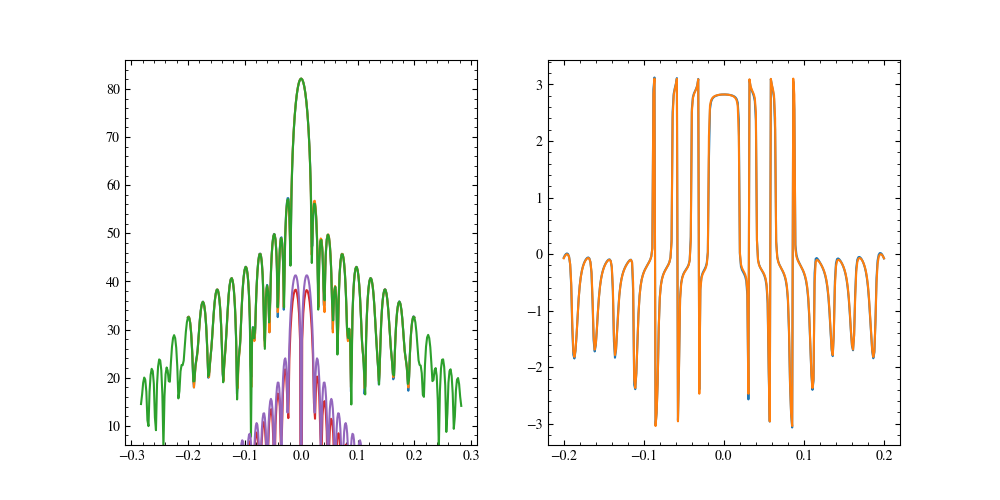

In [41]:
field = s.fields['EH_FF']
grid = s.generateGrids('plane_ff')
shape = grid.x.shape

fig, ax = plt.subplots(1,2, figsize=(10,5))

x = np.rad2deg(grid.x * np.cos(grid.y))
y = np.rad2deg(grid.x * np.sin(grid.y))

# X cut
ax[0].plot(x[:, int(shape[1]/2)], 20*np.log10(np.abs(field.Ex[:, int(shape[1]/2)])))
ax[1].plot(x[:, int(shape[1]/2)], np.angle(field.Ex[:, int(shape[1]/2)]))

# Y cut
ax[0].plot(y[int(shape[0]/2), :], 20*np.log10(np.abs(field.Ex[int(shape[0]/2), :])))
ax[1].plot(y[int(shape[0]/2), :], np.angle(field.Ex[int(shape[0]/2), :]))

# 45° cut
r = np.diagonal(x)*np.sqrt(2)
ax[0].plot(r, 20*np.log10(np.abs(np.diagonal(field.Ex))))

# 45° x-pol cut
ax[0].plot(r, 20*np.log10(np.abs(np.diagonal(field.Ey))))
# Y x-pol cut
ax[0].plot(y[int(shape[0]/2), :], 20*np.log10(np.abs(field.Ey[int(shape[0]/2), :])))

ax[0].set_ylim([6,86])

(-14.0, 86.0)

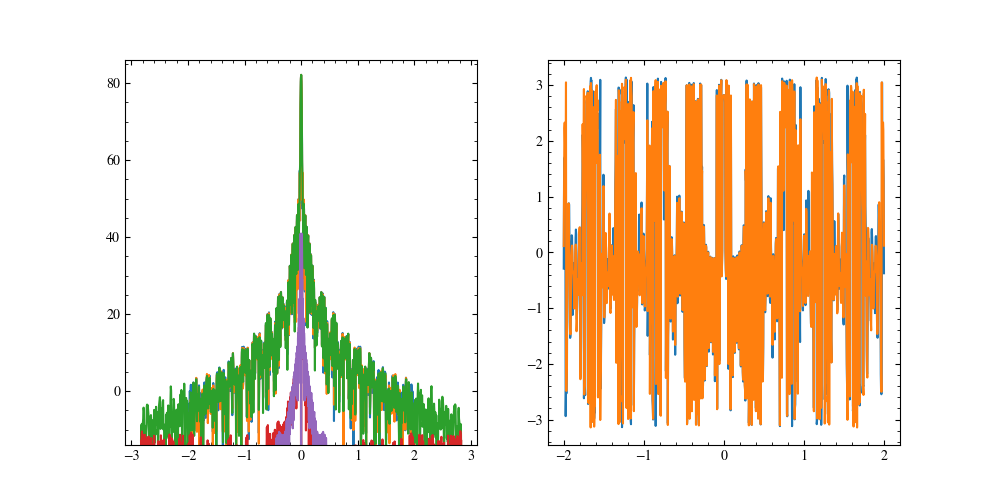

In [42]:
field = s.fields['EH_FF_large']
grid = s.generateGrids('plane_ff_large')
shape = grid.x.shape

fig, ax = plt.subplots(1,2, figsize=(10,5))

x = np.rad2deg(grid.x * np.cos(grid.y))
y = np.rad2deg(grid.x * np.sin(grid.y))

# X cut
ax[0].plot(x[:, int(shape[1]/2)], 20*np.log10(np.abs(field.Ex[:, int(shape[1]/2)])))
ax[1].plot(x[:, int(shape[1]/2)], np.angle(field.Ex[:, int(shape[1]/2)]))

# Y cut
ax[0].plot(y[int(shape[0]/2), :], 20*np.log10(np.abs(field.Ex[int(shape[0]/2), :])))
ax[1].plot(y[int(shape[0]/2), :], np.angle(field.Ex[int(shape[0]/2), :]))

# 45° cut
r = np.diagonal(x)*np.sqrt(2)
ax[0].plot(r, 20*np.log10(np.abs(np.diagonal(field.Ex))))

# 45° x-pol cut
ax[0].plot(r, 20*np.log10(np.abs(np.diagonal(field.Ey))))
# Y x-pol cut
ax[0].plot(y[int(shape[0]/2), :], 20*np.log10(np.abs(field.Ey[int(shape[0]/2), :])))

ax[0].set_ylim([-14,86])

In [43]:
import os.path

path = os.path.join("results", "sma_beamwaveguide")

for f in s.fields.keys():
    filename = os.path.join(path, f + '_fields')
    grid = s.generateGrids(s.fields[f].surf)
    np.savez_compressed(filename, **s.fields[f].__dict__)
    np.savez_compressed(filename+"_grid", **grid.__dict__)
    
    
    
for f in s.currents.keys():
    filename = os.path.join(path, f + '_currents')
    np.savez_compressed(filename, **s.currents[f].__dict__)
    np.savez_compressed(filename+"_grid", **grid.__dict__)

In [44]:
for key in s.system.keys():
    print(f"{key} : {s.system[key]["gridsize"]}")

feed_plane : [210 330]
secondary : [315 780]
primary : [380 740]
sec_plane : [301 360]
farfield_plane : [301 301]
flat_M3 : [101 180]
quadric_M4 : [301 720]
quadric_M5 : [401 960]
flat_M6 : [ 464 1440]
plane_ff : [301 301]
plane_ff_large : [1001 1001]
